# 13 — Sampling MPC: Session 2 平坦チューニング

**目的:** `sigma_mppi` / 歩調を触り、サンプリング MPC の感度を体感。

> **Sampling トラック（Notebook 12–15）** — 既存 Session 1–4（nominal acados）を **壊さず** 並行追加。  
> 技術: Turrisi et al. **IROS 2024** — JAX **MPPI**（`mpc_params.type: sampling`）。  
> preset: `session0X_*_sampling.yaml` · 結果 JSON: `assets/sampling_lab_results.json`


## Nominal vs Sampling（同シナリオ）

| | **Nominal（01–05）** | **Sampling（12–15）** |
|---|---------------------|------------------------|
| **論文** | Elobaid RAL 2025 centroidal NMPC | Turrisi IROS 2024 sample-based MPC |
| **求解** | acados 勾配法 | JAX MPPI ロールアウト |
| **GRF** | 最適化変数（明示） | サンプル軌道から選択 |
| **足場 opt** | Session 3–4 で ON | **非対応**（gradient 専用） |
| **preset** | `session0X_*` | `session0X_*_sampling` |


### 参照: Nominal Session 2 GIF

Markdown の `![](../assets/...)` だけでは IDE 内で見えないことがあります。下のセルで **GIF を直接表示** します。

--- s02_tune ---
  scene: flat
  final_x_m: 1.263
  gif_playback_s: 10.0


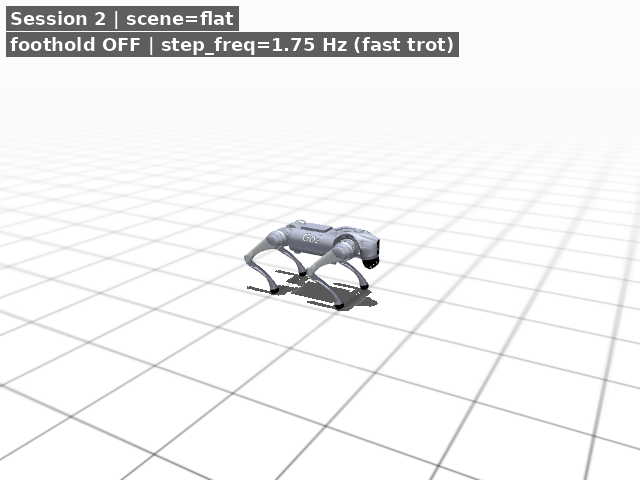

In [1]:
from pathlib import Path
import sys
import json
from IPython.display import Image, display

ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "scripts" / "pympc_lab.py").exists():
        ROOT = p
        break

def show_demo_gifs(tags):
    for tag in tags:
        gif = ROOT / f"docs/pympc_2day/assets/demo_{tag}.gif"
        meta_path = ROOT / f"docs/pympc_2day/assets/demo_{tag}.meta.json"
        print(f"--- {tag} ---")
        if meta_path.is_file():
            m = json.loads(meta_path.read_text())
            for k in ("scene", "final_x_m", "final_dist_m", "gif_playback_s", "falls"):
                if m.get(k) is not None:
                    print(f"  {k}: {m[k]}")
        if gif.is_file():
            display(Image(filename=str(gif)))
        else:
            print("  MISSING:", gif)

show_demo_gifs(["s02_tune"])


In [2]:
import sys
from pathlib import Path

# mpc_dog ルートを sys.path に追加
ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "scripts" / "pympc_lab.py").exists():
        ROOT = p
        break
sys.path.insert(0, str(ROOT / "scripts"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pympc_lab import (
    TUNING_GUIDE,
    apply_preset,
    compare_runs,
    load_param_study,
    load_preset_yaml,
    plot_friction_cone,
    run_flat_sim,
    run_speed_terrain_sim,
    run_speed_terrain_sim_resilient,
)

from tuning_labs import (
    TUNING_LABS,
    list_labs,
    run_lab,
    run_lab_pair,
    plot_speed_trial_journey,
    plot_param_study_mu,
    load_cached_lab_results,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4)
print(f"repo: {ROOT}")

try:
    import jax
    print("JAX", jax.__version__, jax.devices())
except ImportError as e:
    raise ImportError("Install: uv pip install jax jaxlib") from e

from sampling_labs import list_labs, run_lab, load_results, compare_table, SAMPLING_LABS


repo: /home/takuya/work/mpc_dog


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


JAX 0.10.2 [CpuDevice(id=0)]


backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session02_flat_tune_sampling/config.py.bak.20260818T231004Z
applied: session02_flat_tune_sampling -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: Notebook 13: compare sigma_mppi and nominal vs sampling side-by-side.


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


backup: /home/takuya/work/mpc_dog/logs/pympc_sessions/session02_flat_tune_sampling/config.py.bak.20260818T231014Z
applied: session02_flat_tune_sampling -> /home/takuya/work/mpc_dog/external/Quadruped-PyMPC/quadruped_pympc/config.py
notes: Notebook 13: compare sigma_mppi and nominal vs sampling side-by-side.


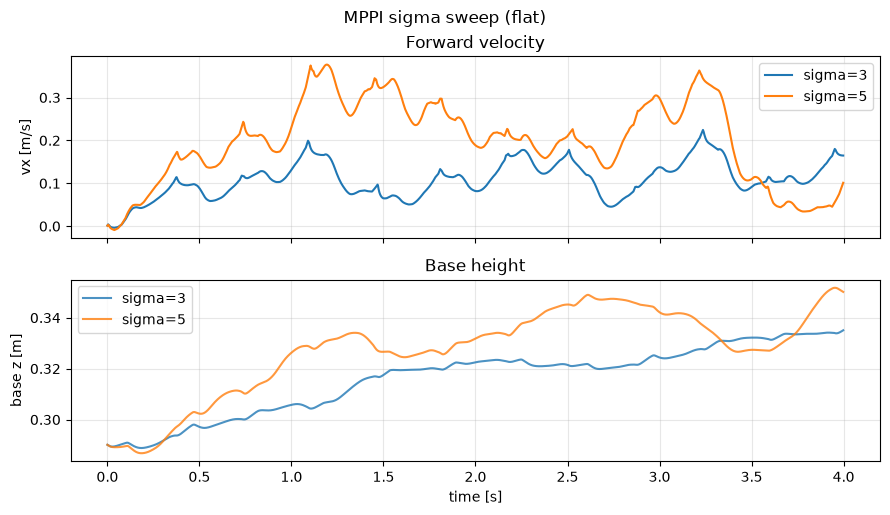

In [3]:
apply_preset("session02_flat_tune_sampling")
base = run_flat_sim(seconds=4.0)
apply_preset("session02_flat_tune_sampling")
from pympc_lab import patch_config
patch_config(**{"mpc.sigma_mppi": 5.0})
high_sigma = run_flat_sim(seconds=4.0)
fig = compare_runs([("sigma=3", base), ("sigma=5", high_sigma)])
plt.suptitle("MPPI sigma sweep (flat)", y=1.02)
plt.show()


In [4]:
data = load_results()
if "smp_s2_flat" in data:
    display(pd.DataFrame([data["smp_s2_flat"]["result"]]))
print("Re-run benchmark: python scripts/run_sampling_benchmark.py --lab smp_s2_flat")


,mean_vx,std_vx,min_z,max_roll_deg,steps,terminated
0,0.118061,0.040111,0.288874,2.370589,2000,False


Re-run benchmark: python scripts/run_sampling_benchmark.py --lab smp_s2_flat
